## Data Preprocessing

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
file = "Customer_Churn_Data_Large.xlsx"

In [4]:
demographics = pd.read_excel(file, sheet_name = "Customer_Demographics")

In [5]:
transactions = pd.read_excel(file, sheet_name="Transaction_History")
service = pd.read_excel(file, sheet_name="Customer_Service")
online = pd.read_excel(file, sheet_name="Online_Activity")
churn = pd.read_excel(file, sheet_name="Churn_Status")

In [6]:
transaction_summary = transactions.groupby("CustomerID").agg(
    TotalSpent=("AmountSpent","sum"),
    TransactionCount=("TransactionID","count")
).reset_index()

In [7]:
service_summary = service.groupby("CustomerID").agg(
    SupportCases=("InteractionID","count")
).reset_index()

In [8]:
data = demographics
data = data.merge(transaction_summary, on="CustomerID", how="left")

In [9]:
data = data.merge(service_summary, on="CustomerID", how="left")

In [10]:
data = data.merge(online, on="CustomerID", how="left")

In [11]:
data = data.merge(churn, on="CustomerID", how="left")

In [12]:
data.head(5)  

,CustomerID,Age,Gender,MaritalStatus,IncomeLevel,TotalSpent,TransactionCount,SupportCases,LastLoginDate,LoginFrequency,ServiceUsage,ChurnStatus
0,1,62,M,Single,Low,416.50,1,1.0,2023-10-21,34,Mobile App,0
1,2,65,M,Married,Low,1547.42,7,1.0,2023-12-05,5,Website,1
2,3,18,M,Single,Low,1702.98,6,1.0,2023-11-15,3,Website,0
3,4,21,M,Widowed,Low,917.29,5,2.0,2023-08-25,2,Website,0
4,5,21,M,Divorced,Medium,2001.49,8,NaN,2023-10-27,41,Website,0


In [13]:
data.fillna(0, inplace=True)

## Exploratory Data Analysis

In [14]:
data['ChurnStatus'].value_counts()

ChurnStatus
0    796
1    204
Name: count, dtype: int64

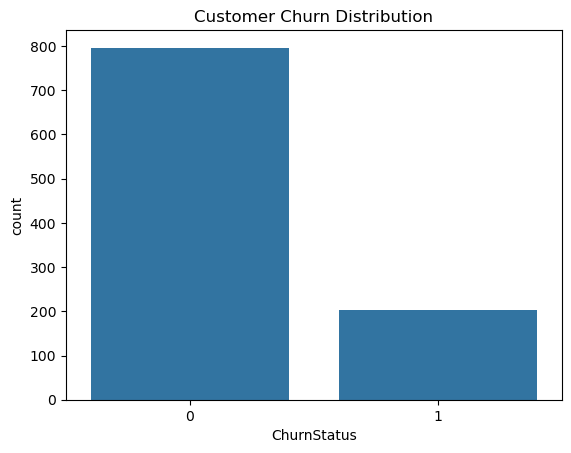

In [16]:
sns.countplot(x='ChurnStatus', data=data)
plt.title("Customer Churn Distribution")
plt.show()

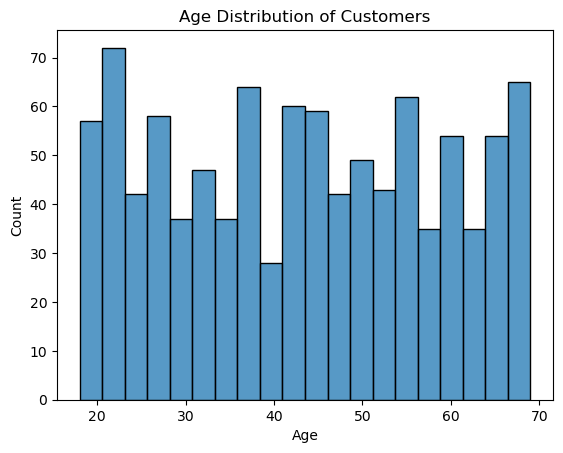

In [17]:
sns.histplot(data['Age'], bins=20)
plt.title("Age Distribution of Customers")
plt.show()

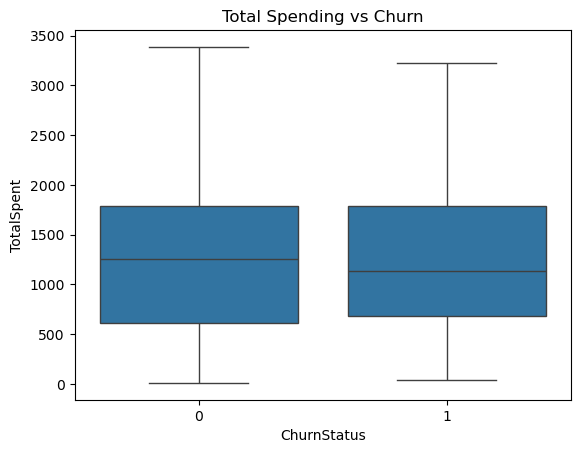

In [18]:
sns.boxplot(x='ChurnStatus', y='TotalSpent', data=data)
plt.title("Total Spending vs Churn")
plt.show()

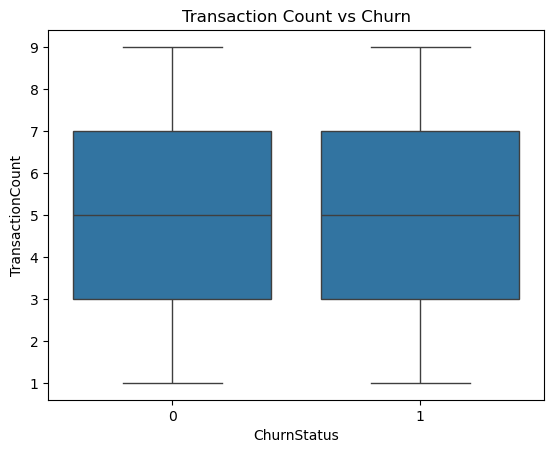

In [19]:
sns.boxplot(x='ChurnStatus', y='TransactionCount', data=data)
plt.title("Transaction Count vs Churn")
plt.show()

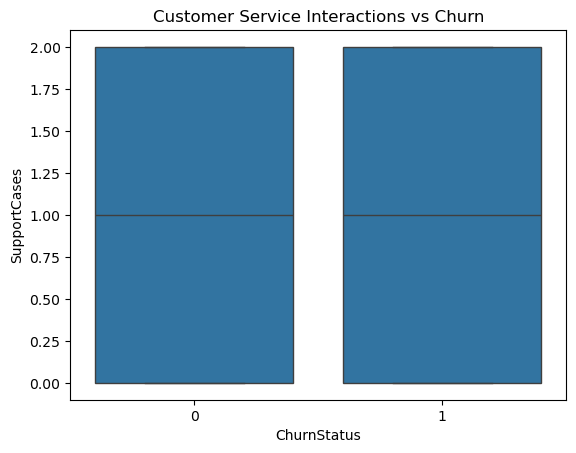

In [20]:
sns.boxplot(x='ChurnStatus', y='SupportCases', data=data)
plt.title("Customer Service Interactions vs Churn")
plt.show()

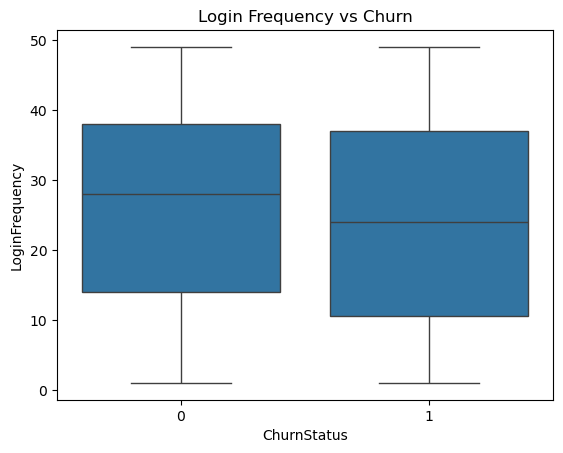

In [21]:
sns.boxplot(x='ChurnStatus', y='LoginFrequency', data=data)
plt.title("Login Frequency vs Churn")
plt.show()

## Feature Engineering

In [23]:
data.to_csv("customer_churn_cleaned.csv", index=False)

In [24]:
data = pd.read_csv("customer_churn_cleaned.csv")

data.head()

,CustomerID,Age,Gender,MaritalStatus,IncomeLevel,TotalSpent,TransactionCount,SupportCases,LastLoginDate,LoginFrequency,ServiceUsage,ChurnStatus
0,1,62,M,Single,Low,416.50,1,1.0,2023-10-21,34,Mobile App,0
1,2,65,M,Married,Low,1547.42,7,1.0,2023-12-05,5,Website,1
2,3,18,M,Single,Low,1702.98,6,1.0,2023-11-15,3,Website,0
3,4,21,M,Widowed,Low,917.29,5,2.0,2023-08-25,2,Website,0
4,5,21,M,Divorced,Medium,2001.49,8,0.0,2023-10-27,41,Website,0


In [25]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   CustomerID        1000 non-null   int64  
 1   Age               1000 non-null   int64  
 2   Gender            1000 non-null   object 
 3   MaritalStatus     1000 non-null   object 
 4   IncomeLevel       1000 non-null   object 
 5   TotalSpent        1000 non-null   float64
 6   TransactionCount  1000 non-null   int64  
 7   SupportCases      1000 non-null   float64
 8   LastLoginDate     1000 non-null   object 
 9   LoginFrequency    1000 non-null   int64  
 10  ServiceUsage      1000 non-null   object 
 11  ChurnStatus       1000 non-null   int64  
dtypes: float64(2), int64(5), object(5)
memory usage: 93.9+ KB


In [26]:
data.describe()

,CustomerID,Age,TotalSpent,TransactionCount,SupportCases,LoginFrequency,ChurnStatus
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,43.267000,1267.074950,5.054000,1.002000,25.912000,0.204000
std,288.819436,15.242311,738.590013,2.603433,0.816494,14.055953,0.403171
min,1.000000,18.000000,9.800000,1.000000,0.000000,1.000000,0.000000
25%,250.750000,30.000000,626.685000,3.000000,0.000000,13.750000,0.000000
50%,500.500000,43.000000,1232.880000,5.000000,1.000000,27.000000,0.000000
75%,750.250000,56.000000,1791.902500,7.000000,2.000000,38.000000,0.000000
max,1000.000000,69.000000,3386.040000,9.000000,2.000000,49.000000,1.000000


In [27]:
X = data.drop(['CustomerID','ChurnStatus'], axis=1)
y = data['ChurnStatus']

## Model Selection

In [28]:
X = pd.get_dummies(X, drop_first=True)

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [30]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [31]:
y_pred = model.predict(X_test)

## Evaluate the Model

In [32]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.745


## Confusion Matrix

In [33]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[149   1]
 [ 50   0]]


## Classification Report

In [34]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.75      0.99      0.85       150
           1       0.00      0.00      0.00        50

    accuracy                           0.74       200
   macro avg       0.37      0.50      0.43       200
weighted avg       0.56      0.74      0.64       200



## Identify Important Features

In [35]:
import pandas as pd

feature_importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(feature_importance)

LoginFrequency              0.090924
TotalSpent                  0.082858
Age                         0.080968
TransactionCount            0.053166
SupportCases                0.029604
                              ...   
LastLoginDate_2023-09-05    0.000000
LastLoginDate_2023-09-09    0.000000
LastLoginDate_2023-09-12    0.000000
LastLoginDate_2023-09-19    0.000000
LastLoginDate_2023-05-29    0.000000
Length: 352, dtype: float64


## Visualize Feature Importance

import matplotlib.pyplot as plt

feature_importance.plot(kind='bar')
plt.title("Feature Importance for Churn Prediction")
plt.show()